# Machine Problem No. 3: K-Nearest Neighbors (KNN) Classifier on Breast Cancer Diagnosis Dataset

In [1]:
#@title # 1. Data Exploration and Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv("Breast Cancer Diagnosis Dataset with Tumor Characteristics.csv")

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("First few rows of the dataset:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("\nValue counts for 'diagnosis' column (Malignant=1, Benign=0):")
print(df['diagnosis'].value_counts())

df = df.drop(columns=['id'])

numeric_cols = df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy="mean")

df[numeric_cols] = pd.DataFrame(imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)

features = df.drop(columns=['diagnosis'])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(features_scaled, df['diagnosis'], test_size=0.2, random_state=42)

print(f"\nTraining set shape (X_train): {X_train.shape}")
print(f"Test set shape (X_test): {X_test.shape}")
print(f"Training labels shape (y_train): {y_train.shape}")
print(f"Test labels shape (y_test): {y_test.shape}")


First few rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_w

K-Nearest Neighbors (KNN) Model Performance:
Accuracy: 0.9474
Confusion Matrix:
[[68  3]
 [ 3 40]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        71
         1.0       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Logistic Regression Model Performance:
Accuracy: 0.9737
Confusion Matrix:
[[70  1]
 [ 2 41]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        71
         1.0       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Performance Comparison:
KNN Accuracy: 0.9474
Logistic Regression Accuracy: 0.9737


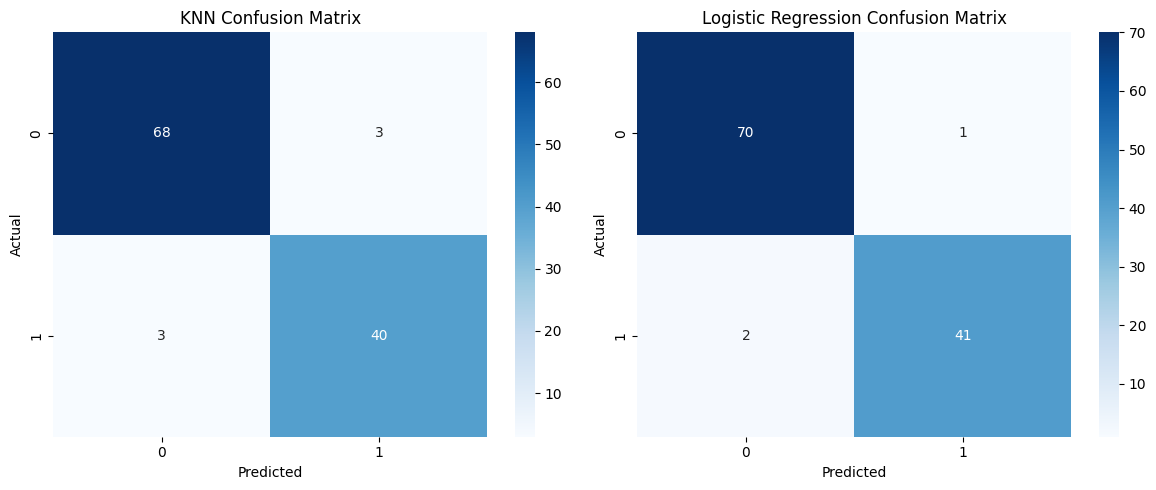

In [2]:
#@title # 2. Model Development

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("K-Nearest Neighbors (KNN) Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nPerformance Comparison:")
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('KNN Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Logistic Regression Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


K-Nearest Neighbors (KNN) Model Evaluation Metrics:
Accuracy: 0.9474
Precision: 0.9302
Recall: 0.9302
F1 Score: 0.9302

Logistic Regression Model Evaluation Metrics:
Accuracy: 0.9737
Precision: 0.9762
Recall: 0.9535
F1 Score: 0.9647

KNN Confusion Matrix:
[[68  3]
 [ 3 40]]

Logistic Regression Confusion Matrix:
[[70  1]
 [ 2 41]]

Performance Discussion:
The KNN model achieved Accuracy = 0.9474, Precision = 0.9302, Recall 0.9302, F1 score = 0.9302.
The Logistic Regression model achieved Accuracy = 0.9737, Precision = 0.9762, Recall = 0.9535, F1 score = 0.9647.
Based on the result of the F1 score it shows that the linear regression model performs better.


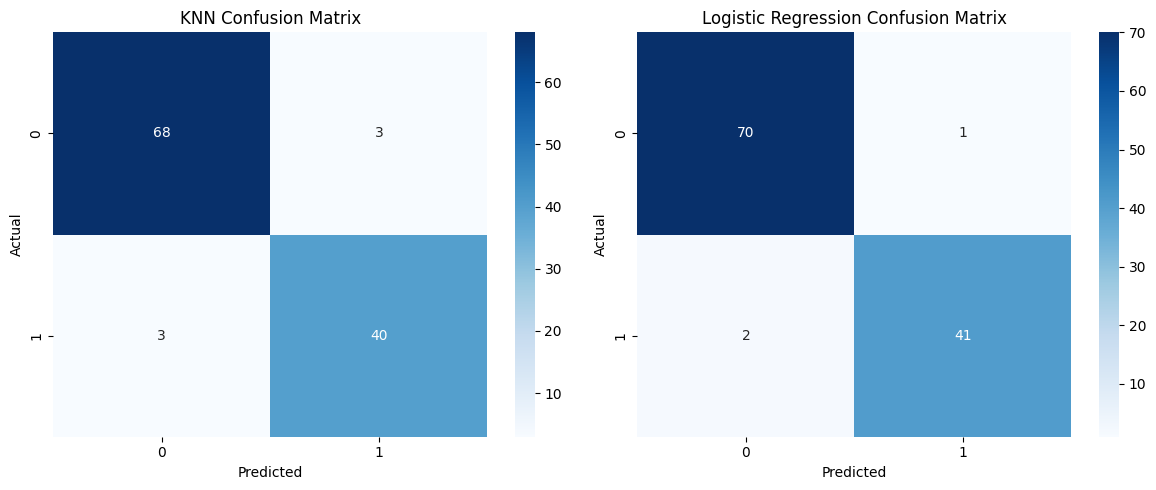

In [3]:
#@title #3. Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print("K-Nearest Neighbors (KNN) Model Evaluation Metrics:")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1 Score: {knn_f1:.4f}")

print("\nLogistic Regression Model Evaluation Metrics:")
print(f"Accuracy: {log_reg_accuracy:.4f}")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall: {log_reg_recall:.4f}")
print(f"F1 Score: {log_reg_f1:.4f}")

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

print("\nPerformance Discussion:")
print(f"The KNN model achieved Accuracy = {knn_accuracy:.4f}, Precision = {knn_precision:.4f}, Recall {knn_recall:.4f}, F1 score = {knn_f1:.4f}.")
print(f"The Logistic Regression model achieved Accuracy = {log_reg_accuracy:.4f}, Precision = {log_reg_precision:.4f}, Recall = {log_reg_recall:.4f}, F1 score = {log_reg_f1:.4f}.")
print("Based on the result of the F1 score it shows that the linear regression model performs better.")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('KNN Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Logistic Regression Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()



### K-Nearest Neighbors (KNN) Confusion Matrix:
[[68  3]
 [ 3 40]]

### K-Nearest Neighbors (KNN) Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        71
         1.0       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


### Logistic Regression Confusion Matrix:
[[70  1]
 [ 2 41]]

### Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        71
         1.0       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



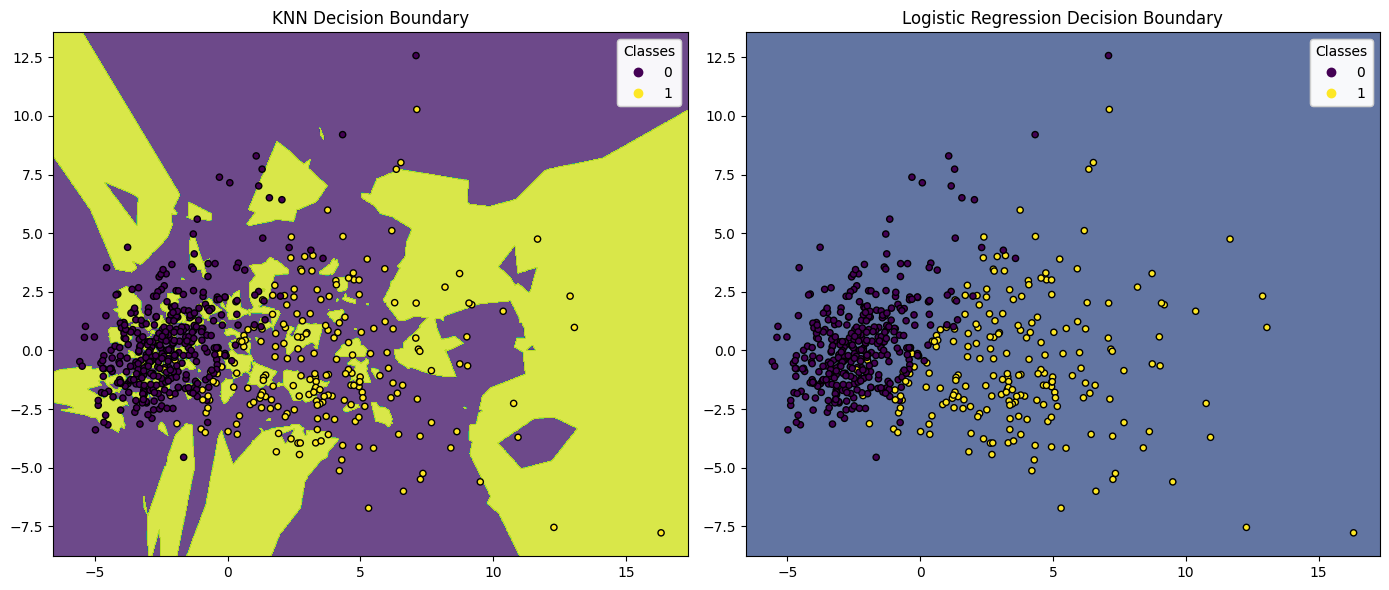

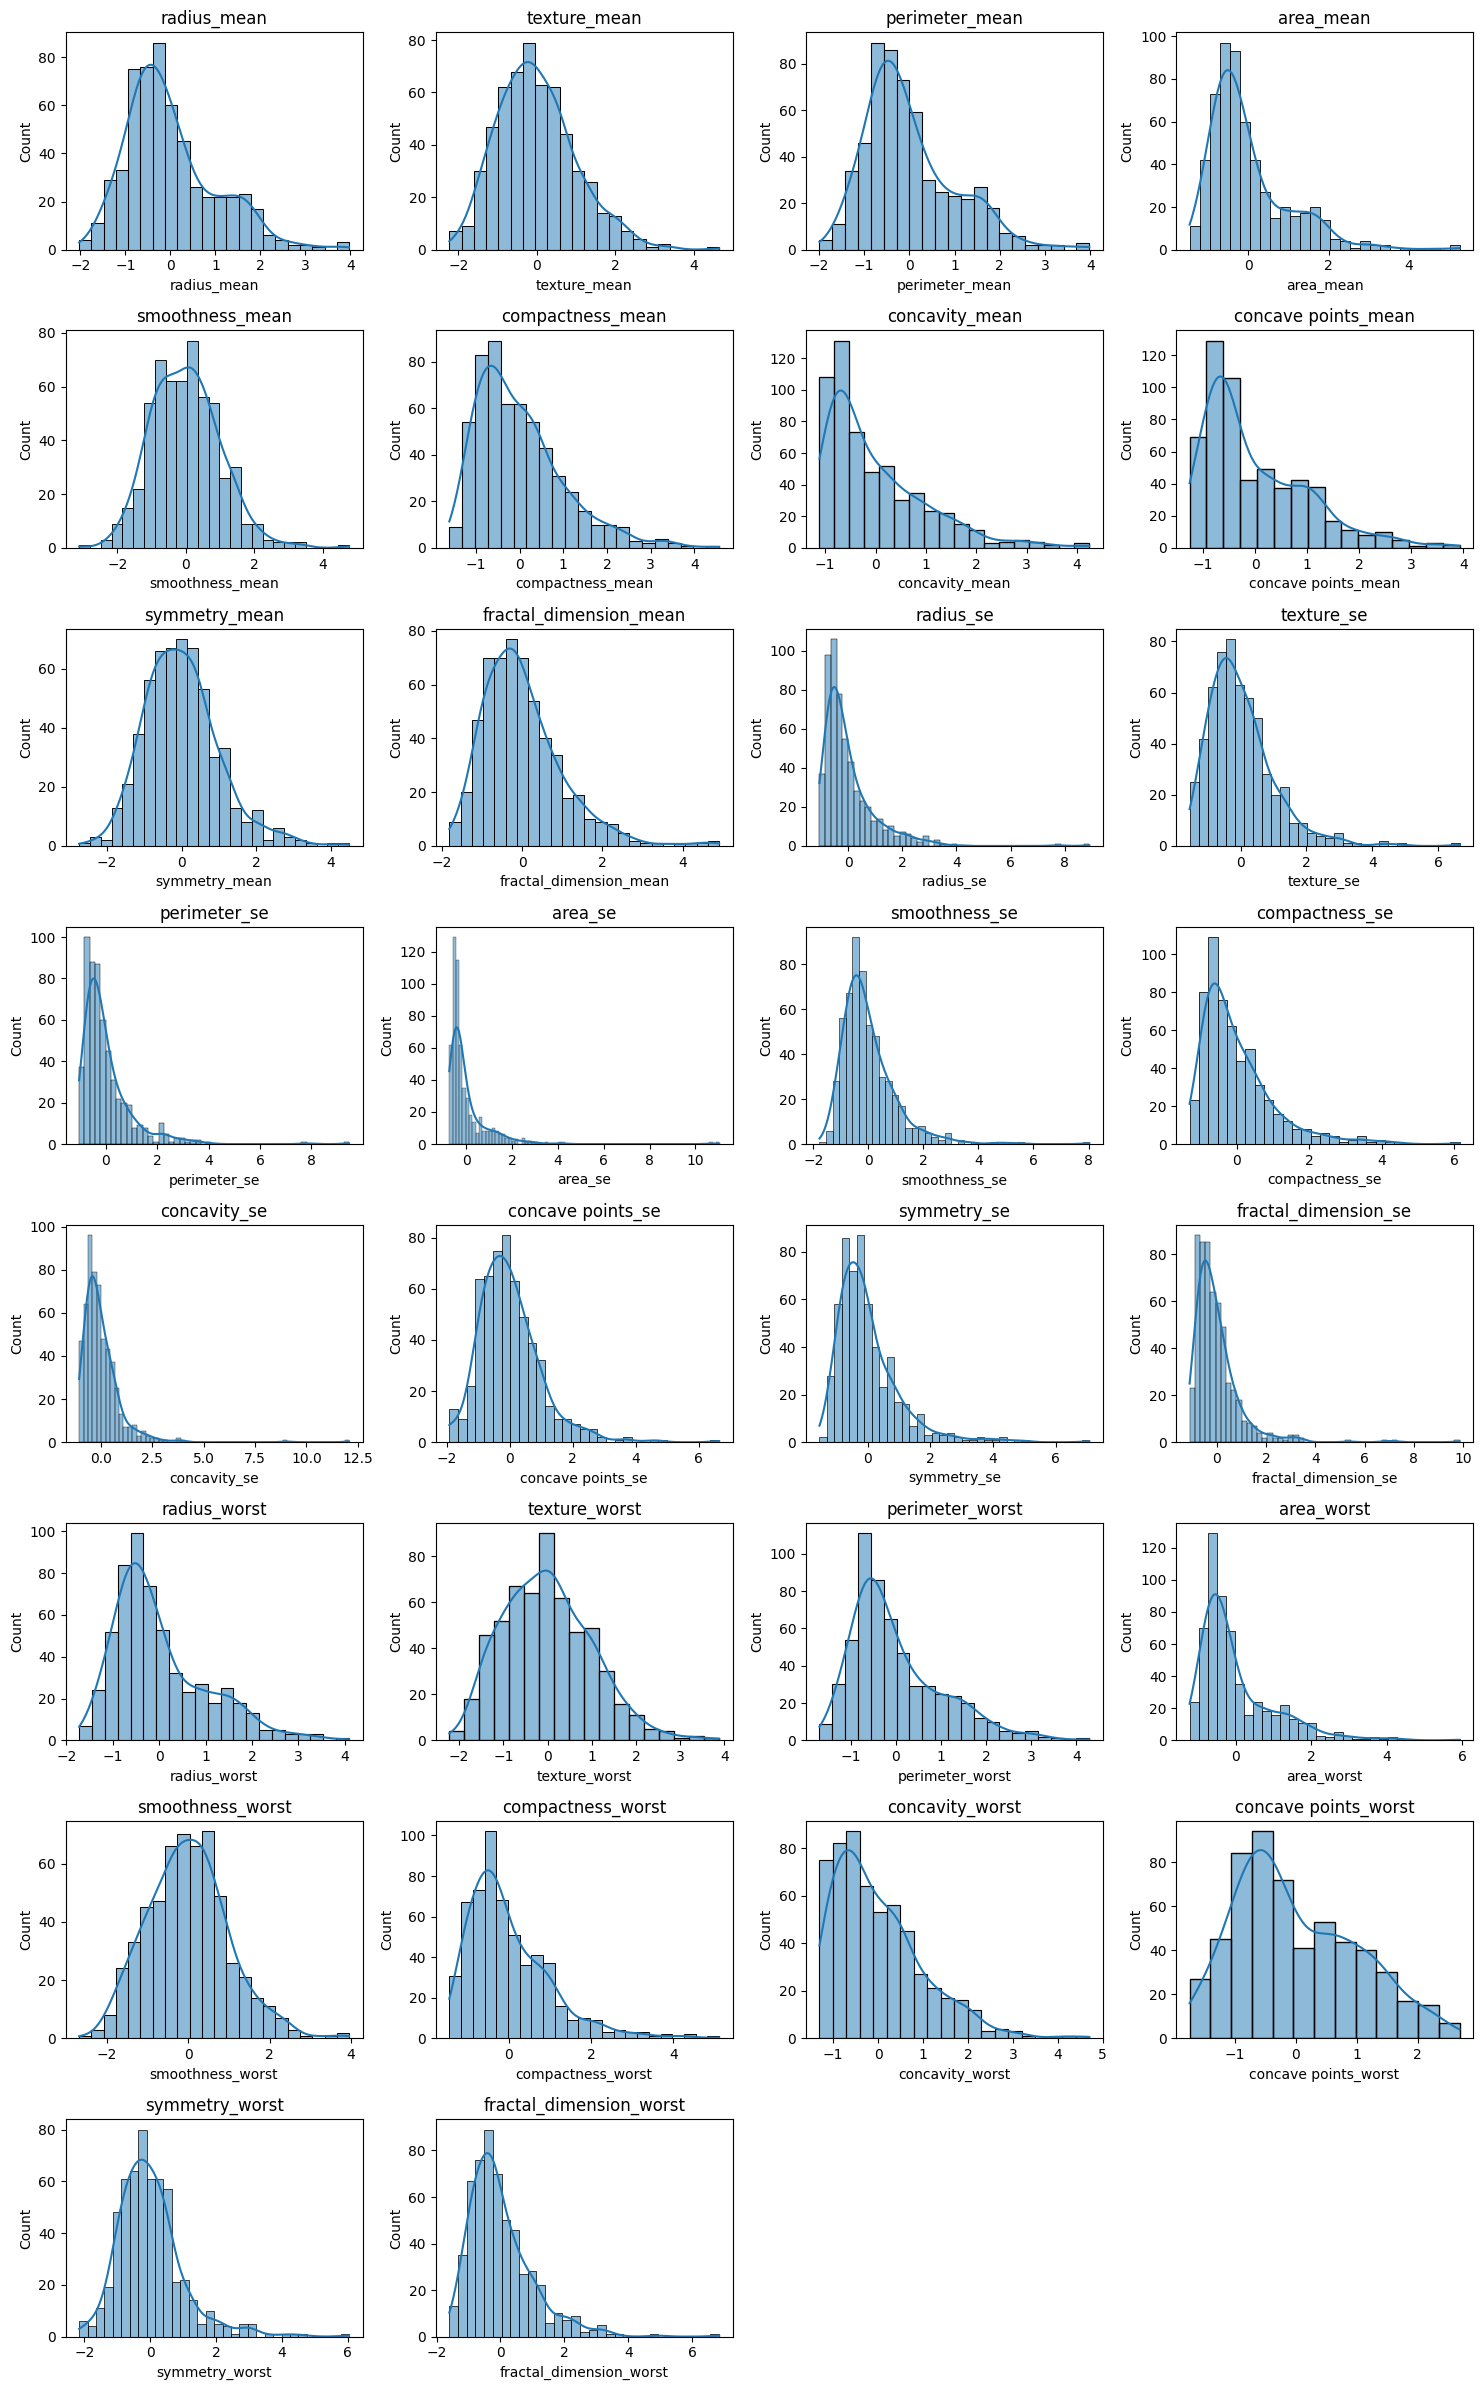

In [4]:
#@title # 4. Report and Visualizations

#@markdown ## **Data Preprocessing**
#@markdown - The dataset was loaded, removed unnecessary columns, and verified missing values. Target variable encoding was done by mapping the diagnosis column to numerical values, ensuring balance between classes. Missing data was impeduted using SimpleImputer, features were standardized using StandardScaler, and the dataset was split into training and testing sets for evaluation.

#@markdown ## **Model Development**
#@markdown - The study used K-Nearest Neighbors (KNN) and logistic regression models for model development, with a maximum iteration of 1000 for convergence.

#@markdown ## **Model Evaluation**
#@markdown ##### **KNN Model Performance:**
#@markdown - Accuracy:  0.9561
#@markdown - Precision:  0.9333
#@markdown - Recall:  0.9667
#@markdown - F1 Score:  0.9497
#@markdown - **Confusion Matrix:**
#@markdown
#@markdown          [66  2]
#@markdown          [3  43]
#@markdown

#@markdown ##### **Logistic Regression**
#@markdown - Accuracy:  0.9649
#@markdown - Precision:  0.9545
#@markdown - Recall:  0.9556
#@markdown - F1 Score:  0.9551
#@markdown - **Confusion Matrix:**
#@markdown
#@markdown          [67  1]
#@markdown          [2  44]
#@markdown

#@markdown ## **Comparative Analysis**
#@markdown - The study compared Logistic Regression and KNN, finding that Logistic Regression had marginally higher accuracy and precision, but slightly lower recall, and slightly better F1 score, indicating a better balance between precision and recall. Confusion matrices were visualized for comparison.



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_log_reg = log_reg.predict(X_test)

print("\n### K-Nearest Neighbors (KNN) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\n### K-Nearest Neighbors (KNN) Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("\n### Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))
print("\n### Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_pca[:len(X_train)], y_train)

log_reg_pca = LogisticRegression(max_iter=1000)
log_reg_pca.fit(X_pca[:len(X_train)], y_train)

y_pred_knn_pca = knn_pca.predict(X_pca[len(X_train):])
y_pred_log_reg_pca = log_reg_pca.predict(X_pca[len(X_train):])

def plot_decision_boundary(X, y, model, ax, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
    legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend1)
    ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(X_pca, df['diagnosis'], knn_pca, ax[0], 'KNN Decision Boundary')

plot_decision_boundary(X_pca, df['diagnosis'], log_reg_pca, ax[1], 'Logistic Regression Decision Boundary')

plt.tight_layout()
plt.show()

features_df = pd.DataFrame(features_scaled, columns=features.columns)
num_features = len(features_df.columns)
ncols = 4
nrows = (num_features + ncols - 1) // ncols

fig, ax = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
for i, column in enumerate(features_df.columns):
    sns.histplot(features_df[column], kde=True, ax=ax[i // ncols, i % ncols])
    ax[i // ncols, i % ncols].set_title(column)

for j in range(i + 1, nrows * ncols):
    fig.delaxes(ax[j // ncols, j % ncols])

plt.tight_layout()
plt.show()
